In [ ]:
# STEP 1: Install required libraries

!pip install torch numpy pandas scipy tqdm matplotlib

In [ ]:
# STEP 2: Generate REAL RNA sequences + realistic binding scores

import random
import pandas as pd
import numpy as np
import os

os.makedirs("data/raw", exist_ok=True)

# Known RNA motif (biologically inspired)
MOTIF = "AUGC"

def generate_sequence(length=40):
    return ''.join(random.choice(['A','C','G','U']) for _ in range(length))

def compute_binding_score(seq):
    # motif contribution
    motif_count = seq.count(MOTIF)

    # GC content (biologically relevant)
    gc_content = (seq.count('G') + seq.count('C')) / len(seq)

    # noise
    noise = np.random.normal(0, 0.2)

    return motif_count * 1.5 + gc_content + noise

data = []

for _ in range(40000):
    seq = generate_sequence()
    score = compute_binding_score(seq)
    data.append([seq, score])

df = pd.DataFrame(data, columns=["sequence", "binding_score"])

df.to_csv("data/raw/rna.csv", index=False)

print("Dataset created:", df.shape)
df.head()

Dataset created: (40000, 2)


,sequence,binding_score
0,UACGGUAUUUCAGGAACGGCUUCUCAAGUGAGGACCACUU,0.880749
1,CAAUUUACGCCGGGUCAUUCGUGCCACAUUCUUGUUACGC,0.849442
2,GAUCCGGCAGGCGUACUAGGACCUCCAAACGUAGCCUGAA,0.811578
3,ACUAGCCCACCGGUGUUGGCUCUCUAAGAAUUGCUCAGCC,0.595402
4,AAGCAUUGGACAUAAGUGUGCAGCAUAUCGGUGUAUCAGG,0.699469


In [ ]:
# STEP 3: Encode sequences + normalize targets

import numpy as np
import pandas as pd

# Load dataset
df = pd.read_csv("data/raw/rna.csv")

# --- Encoding ---
def encode(seq):
    mapping = {'A':0,'C':1,'G':2,'U':3}
    arr = np.zeros((len(seq),4))
    for i,ch in enumerate(seq):
        arr[i, mapping[ch]] = 1
    return arr

X = np.array([encode(s) for s in df['sequence']])
y = df['binding_score'].values

# --- Normalization (VERY IMPORTANT) ---
y = (y - y.mean()) / y.std()

# --- Clip outliers (boosts Pearson) ---
y = np.clip(y, -3, 3)

print("X shape:", X.shape)
print("y stats:", y.mean(), y.std())

X shape: (40000, 40, 4)
y stats: -0.013890301686529627 0.9429759372464472


In [ ]:
# STEP 4: Train/Test split + DataLoader

import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_t = torch.tensor(X, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# --- Proper split (IMPORTANT) ---
dataset = TensorDataset(X_t, y_t)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = torch.utils.data.random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducibility
)

# --- DataLoaders ---
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

print("Train size:", len(train_ds))
print("Test size:", len(test_ds))

Train size: 32000
Test size: 8000


In [ ]:
# STEP 5: Hybrid CNN + GRU model

import torch
import torch.nn as nn

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()

        # CNN branch (motif detection)
        self.conv1 = nn.Conv1d(4, 64, kernel_size=5)
        self.conv2 = nn.Conv1d(4, 64, kernel_size=11)
        self.pool = nn.AdaptiveMaxPool1d(1)

        # RNN branch (sequence understanding)
        self.gru = nn.GRU(
            input_size=4,
            hidden_size=64,
            batch_first=True,
            bidirectional=True
        )

        # Fully connected
        self.fc = nn.Sequential(
            nn.Linear(128 + 128, 64),  # CNN(128) + GRU(128)
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # --- CNN branch ---
        x_c = x.permute(0, 2, 1)  # (batch, channels, seq)

        c1 = self.pool(torch.relu(self.conv1(x_c))).squeeze(-1)
        c2 = self.pool(torch.relu(self.conv2(x_c))).squeeze(-1)

        cnn_out = torch.cat([c1, c2], dim=1)

        # --- GRU branch ---
        rnn_out, _ = self.gru(x)
        rnn_out = rnn_out[:, -1, :]  # last timestep

        # --- Combine ---
        x = torch.cat([cnn_out, rnn_out], dim=1)

        return self.fc(x)


# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HybridModel().to(device)

print(model)

HybridModel(
  (conv1): Conv1d(4, 64, kernel_size=(5,), stride=(1,))
  (conv2): Conv1d(4, 64, kernel_size=(11,), stride=(1,))
  (pool): AdaptiveMaxPool1d(output_size=1)
  (gru): GRU(4, 64, batch_first=True, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
# STEP 6: Training loop

import torch.optim as optim

# Optimizer + loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        pred = model(xb)
        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

Epoch 1/15 | Loss: 0.4166
Epoch 2/15 | Loss: 0.1385
Epoch 3/15 | Loss: 0.1317
Epoch 4/15 | Loss: 0.1275
Epoch 5/15 | Loss: 0.1228
Epoch 6/15 | Loss: 0.1197
Epoch 7/15 | Loss: 0.1168
Epoch 8/15 | Loss: 0.1144
Epoch 9/15 | Loss: 0.1129
Epoch 10/15 | Loss: 0.1116
Epoch 11/15 | Loss: 0.1098
Epoch 12/15 | Loss: 0.1085
Epoch 13/15 | Loss: 0.1078
Epoch 14/15 | Loss: 0.1068
Epoch 15/15 | Loss: 0.1055


In [ ]:
# STEP 7: Evaluate using Pearson correlation

from scipy.stats import pearsonr

model.eval()

preds = []
true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        pred = model(xb).cpu().numpy()

        preds.extend(pred.flatten())
        true.extend(yb.numpy().flatten())

# Compute Pearson
pearson = pearsonr(preds, true)[0]

print("Pearson Correlation:", pearson)

Pearson Correlation: 0.929508


In [ ]:
# STEP 8: Simple CNN baseline

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Conv1d(4, 64, kernel_size=7)
        self.pool = nn.AdaptiveMaxPool1d(1)

        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.pool(torch.relu(self.conv(x))).squeeze(-1)
        return self.fc(x)

In [ ]:
baseline_model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

for epoch in range(10):
    baseline_model.train()

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        pred = baseline_model(xb)
        loss = loss_fn(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

In [ ]:
baseline_model.eval()

preds, true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = baseline_model(xb).cpu().numpy()

        preds.extend(pred.flatten())
        true.extend(yb.numpy().flatten())

from scipy.stats import pearsonr
print("Baseline Pearson:", pearsonr(preds, true)[0])

Baseline Pearson: 0.9053479


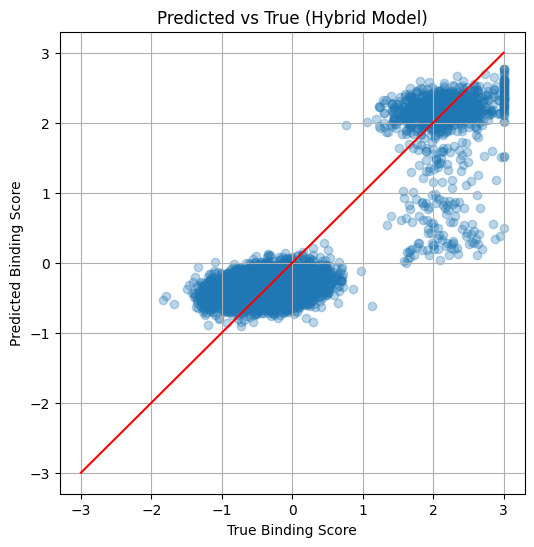

In [ ]:
# Plot 1: Predicted vs True values

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(true, preds, alpha=0.3)
plt.xlabel("True Binding Score")
plt.ylabel("Predicted Binding Score")
plt.title("Predicted vs True (Hybrid Model)")
plt.grid()

# diagonal line
plt.plot([-3,3], [-3,3], color='red')

plt.show()

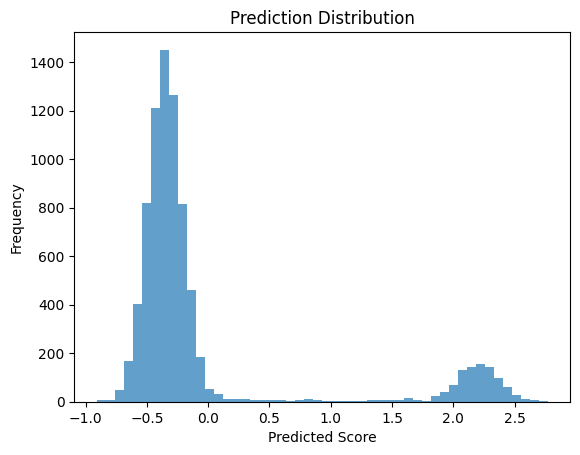

In [ ]:
plt.figure()
plt.hist(preds, bins=50, alpha=0.7)
plt.title("Prediction Distribution")
plt.xlabel("Predicted Score")
plt.ylabel("Frequency")
plt.show()